# Building a Physics-Stratified Seismic Phase Picker Benchmark — Step 1

**Research question:** Can any existing pretrained PhaseNet model already serve as a competent *global* phase picker across all distance regimes, or is retraining on a union of datasets necessary?

**Approach:** Survey pretrained models and datasets in SeisBench, characterise their physics coverage (magnitude, depth, distance), then build a stratified benchmark that enables fair cross-domain evaluation — including, for the first time, teleseismic distances.

**Author:** Akash Kharita, University of Washington
**Date:** May 2026

---

## What this notebook produces

`benchmark_manifest.csv` — a 4,476-trace stratified benchmark with the following properties:

| Property | Value |
|----------|-------|
| Total traces | 4,476 |
| Datasets | 8 (STEAD, SCEDC, INSTANCE, PNW, TXED, MLAAPDE, Iquique, OBST2024) |
| Distance strata | local <150 km · regional 150–1500 km · teleseismic >1500 km |
| Depth strata | 0–15 · 15–70 · 70–300 · >300 km |
| Magnitude strata | M<3 · M3–6 · M>6 |
| Teleseismic source | MLAAPDE (supersedes NEIC; 169K traces, July 2013 – Oct 2014) |
| Pick availability | 3,126 traces with both P+S · 1,349 P-only (MLAAPDE) · 1 S-only |

---

## Table of Contents

1. [1.1 Model Inventory](#1.1)
2. [1.2 Dataset Inventory](#1.2)
3. [1.3 Column Harmonization](#1.3)
4. [1.4 Physics Parameter Distributions](#1.4)
5. [1.4b Label Quality Filtering](#1.4b)
6. [1.5 Benchmark Construction](#1.5)
7. [1.6 Benchmark Summary & Visualisation](#1.6)


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json

# SeisBench cache location
CACHE = Path("/data/wsd04/ak287/.seisbench/datasets")
assert CACHE.exists(), f"SeisBench cache not found at {CACHE}"

<a id='1.1'></a>
## 1.1 Model Inventory

List all pretrained weights available for PhaseNet (16 weights) and EQTransformer (13 weights) in SeisBench. PhaseNet is the primary model family for this study — it takes a fixed 3,000-sample (30 s at 100 Hz) three-component waveform and outputs continuous P, S, and noise probability curves.

These weights are what we will evaluate on the benchmark built in Section 1.5. The tiering below determines which weights are priority candidates versus regional baselines.


In [2]:
import seisbench.models as sbm

print("PhaseNet pretrained weights:")
for w in sbm.PhaseNet.list_pretrained():
    print(f"  {w}")

print("\nEQTransformer pretrained weights:")
for w in sbm.EQTransformer.list_pretrained():
    print(f"  {w}")

PhaseNet pretrained weights:
  diting
  ethz
  geofon
  instance
  iquique
  jma
  jma_wc
  lendb
  neic
  obs
  original
  phasenet_sn
  pisdl
  scedc
  stead
  volpick

EQTransformer pretrained weights:
  ethz
  geofon
  instance
  iquique
  lendb
  neic
  obs
  original
  original_nonconservative
  scedc
  stead
  volpick


In [3]:
# Detailed metadata for each PhaseNet weight
pn_details = sbm.PhaseNet.list_pretrained(details=True)
for name, desc in pn_details.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print(desc[:200] + '...' if len(desc) > 200 else desc)


diting
Model trained on the DiTing dataset, a large-scale Chinese seismic benchmark dataset.
For models fine-tuned on individual regions in China, please see: https://github.com/JUNZHU-SEIS/USTC-Pickers
If y...

ethz
Model trained on ETHZ for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adju...

geofon
Model trained on GEOFON for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be a...

instance
Model trained on INSTANCE for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be...

iquique
Model trained on Iquique for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Dependin

### Model Tiering

Based on training data scope and geographic diversity — **revised with rationale from Münchmeyer et al. (2022)**:

| Tier | Weights | Rationale |
|------|---------|----------|
| **A — Generalist candidates** | `stead`, `instance`, `neic` | Large, diverse training sets with proven cross-domain transfer (Münchmeyer et al., 2022) |
| **B — Specialty / large-regional** | `diting`, `obs`, `volpick`, `pisdl`, `phasenet_sn`, `jma`, `jma_wc` | Unique station/event types *or* large but geographically homogeneous |
| **C — Regional baselines + historical** | `scedc`, `ethz`, `iquique`, `lendb`, `original` | Regional specialists and the original PhaseNet used as reference |
| **D — Teleseismic baselines** | `geofon`, `neic` | Primarily teleseismic distance range |

> **Note on `original`:** Trained on ~780K Northern California waveforms (Zhu & Beroza, 2018) — geographically narrow; treated as a historical baseline rather than a generalist.

> **Note on `diting`:** Largest single-dataset model (~2.7M events) but exclusively Chinese seismicity. Size alone does not guarantee diversity; Münchmeyer et al. (2022) show that *diversity* (multi-region, complex tectonic settings) is the key driver of cross-domain transfer. Moved to Tier B.

> **Note on `neic`:** The `neic` *model weight* is trained on the original NEIC catalog and is still evaluated here (Tier A+D). However, the NEIC *dataset* in SeisBench has been superseded by MLAAPDE (see Section 1.5). The benchmark *traces* at teleseismic distances come from MLAAPDE, not NEIC. Münchmeyer et al. (2022) also note that NEIC picks always appear at a fixed position within the 60 s window, introducing a positional bias particularly for EQTransformer.

> **Note on `geofon`:** Despite the 'broadband' label, ~170K GEOFON traces are at >5,000 km — primarily **teleseismic**, not regional. Reclassified to Tier D. Only 2,583 of 275K traces have both P and S picks (0.9%), so GEOFON is excluded from the benchmark pool.

> **Note on `iquique`:** Only 13,400 training examples. Münchmeyer et al. (2022) explicitly flag this as a low-data regime where all models show wider uncertainty and systematic residual skew. Included as a stress-test regional baseline.

**Key observation for benchmark design:** The `neic` and `geofon` model weights are evaluated primarily for their teleseismic performance. The benchmark provides 1,350 teleseismic traces from MLAAPDE to enable this evaluation — resolving a gap in earlier benchmark designs that had zero teleseismic traces.


<a id='1.2'></a>
## 1.2 Dataset Inventory

Scan the local SeisBench cache to identify which datasets are available, their disk size, and whether metadata exists. This step determines which datasets can be used in the benchmark.

**Key observations from the inventory:**
- **MLAAPDE** (28.8 GB, largest dataset): Supersedes the NEIC dataset. Unlike most SeisBench datasets which store a single `metadata.csv`, MLAAPDE is *sharded by month* — 16 monthly files covering July 2013 to October 2014 (`metadata_YYYYMM.csv` / `waveforms_YYYYMM.hdf5`). The waveforms are already downloaded locally, so no FDSN fetch is needed in Step 2.
- **NEIC** (0.6 GB): Still present in cache but superseded by MLAAPDE. Its SeisBench metadata contains no timestamps or network/station information, making FDSN retrieval impossible. Not used for benchmark traces.
- **GEOFON** (2.8 GB), **LenDB** (16.4 GB): Present but excluded from the benchmark — GEOFON has <1% S picks and LenDB has no S picks at all.
- **INSTANCE** (12.8 GB): Available as `instancecounts` (waveforms in raw count units, no instrument response applied). Largest regional contributor to the benchmark.


In [4]:
# Check which datasets are cached with metadata
print(f"{'Dataset':<20s}  {'Size (GB)':>10s}  {'Has metadata':>12s}")
print("-" * 50)
for d in sorted(CACHE.iterdir()):
    if d.is_dir():
        files = list(d.iterdir())
        has_meta = any('metadata' in f.name for f in files)
        size_gb = sum(f.stat().st_size for f in files if f.is_file()) / 1e9
        print(f"{d.name:<20s}  {size_gb:>10.1f}  {str(has_meta):>12s}")

Dataset                Size (GB)  Has metadata
--------------------------------------------------
ceed                         0.5          True
crew                         0.0         False
dummydataset                 0.0          True
ethz                         0.0          True
geofon                       2.8          True
instancecounts             168.1          True
iquique                      0.0          True
lendb                       16.4          True
meier2019jgr                 0.0         False
mlaapde                     28.8          True
neic                         0.6          True
obst2024                     0.0          True
pnw                         67.4          True
pnwaccelerometers            0.0          True
ross2018gpd                  0.0         False
scedc                       50.3          True
stead                       91.5          True
txed                        75.0          True
vcseis                       0.1          True


<a id='1.3'></a>
## 1.3 Column Harmonization

SeisBench datasets use inconsistent column naming across providers. This section identifies the exact column names for P/S arrival samples, magnitude, depth, distance, and timestamps in each dataset by reading only the first few rows of each metadata CSV.

**Key naming inconsistencies discovered:**
- **Case:** STEAD, SCEDC, TXED, OBST2024 use lowercase `trace_p_arrival_sample`; INSTANCE, PNW, Iquique, MLAAPDE, GEOFON use uppercase `trace_P_arrival_sample`.
- **Distance:** SCEDC uses `station_epicentral_distance` (not the standard `path_ep_distance_km`). PNW, TXED, Iquique, and GEOFON have no distance column at all — epicentral distance is computed from source/station lat/lon using the Haversine formula.
- **MLAAPDE multi-phase columns:** Unlike all other datasets which have a single P and S column, MLAAPDE records 13 phase types (P, Pn, Pg, S, Sn, Sg, PKPab, PKPdf, pP, sP, PKPbc, PKPdif, PcP). For benchmark purposes we use a priority-order coalescing strategy: P → Pn → Pg for the P pick; S → Sn → Sg for the S pick.
- **MLAAPDE sharding:** The column discovery loop checks for monthly files (`metadata_YYYYMM.csv`) when `metadata.csv` doesn't exist.


In [5]:
# Discover pick columns using the SeisBench convention: *_arrival_sample
datasets_to_check = [
    'stead', 'scedc', 'instancecounts', 'pnw', 'txed',
    'obst2024', 'iquique', 'mlaapde', 'geofon', 'lendb',
]

for name in datasets_to_check:
    ds_dir    = CACHE / name
    meta_path = ds_dir / "metadata.csv"

    # MLAAPDE (and any future sharded dataset) uses monthly files
    # instead of a single metadata.csv — pick the first complete one
    if not meta_path.exists():
        monthly = sorted([f for f in ds_dir.glob("metadata_*.csv")
                          if not f.name.endswith(".partial")])
        if monthly:
            meta_path = monthly[0]
        else:
            print(f"{name}: no metadata.csv")
            continue

    df   = pd.read_csv(meta_path, nrows=5, low_memory=False)
    cols = df.columns.tolist()

    arr   = [c for c in cols if c.endswith('_arrival_sample')]
    mag   = [c for c in cols if 'magnitude' in c.lower() and 'type' not in c.lower()]
    depth = [c for c in cols if 'depth' in c.lower()]
    dist  = [c for c in cols if 'distance' in c.lower()]
    time  = [c for c in cols if any(k in c.lower() for k in ['time','date','start'])]

    label = name if meta_path.name == "metadata.csv" else f"{name} ({meta_path.name})"
    print(f"\n{label}")
    print(f"  arrivals:  {arr}")
    print(f"  magnitude: {mag}")
    print(f"  depth:     {depth}")
    print(f"  distance:  {dist}")
    print(f"  time:      {time}")



stead
  arrivals:  ['trace_p_arrival_sample', 'trace_s_arrival_sample']
  magnitude: ['source_magnitude', 'source_magnitude_author']
  depth:     ['source_depth_km', 'source_depth_uncertainty_km']
  distance:  ['source_distance_deg', 'source_distance_km']
  time:      ['source_origin_time', 'trace_start_time']

scedc
  arrivals:  ['trace_p_arrival_sample', 'trace_s_arrival_sample']
  magnitude: ['source_magnitude']
  depth:     ['source_depth_km']
  distance:  ['station_epicentral_distance']
  time:      ['trace_start_time', 'source_origin_time']

instancecounts
  arrivals:  ['trace_P_arrival_sample', 'trace_S_arrival_sample']
  magnitude: ['source_magnitude']
  depth:     ['source_depth_km', 'source_depth_uncertainty_km']
  distance:  ['path_ep_distance_km', 'path_hyp_distance_km']
  time:      ['source_origin_time', 'path_travel_time_P_s', 'path_travel_time_S_s', 'trace_start_time', 'trace_P_arrival_time', 'trace_S_arrival_time', 'trace_E_pga_time', 'trace_E_pgv_time', 'trace_N_pga_

In [6]:
# Count traces with valid P and S picks per dataset
col_map = {
    'stead':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
    'scedc':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
    'instancecounts': {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'pnw':            {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'txed':           {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
    'obst2024':       {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
    'iquique':        {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'mlaapde':        {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'geofon':         {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'lendb':          {'p': 'trace_p_arrival_sample', 's': None},
    'ethz':           {'p': 'trace_P1_arrival_sample','s': 'trace_S1_arrival_sample'},
}

# MLAAPDE has additional phase columns used as fallbacks when P/S are NaN
MLAAPDE_P_FALLBACKS = ['trace_Pn_arrival_sample', 'trace_Pg_arrival_sample']
MLAAPDE_S_FALLBACKS = ['trace_Sn_arrival_sample', 'trace_Sg_arrival_sample']

def get_meta_files(name):
    """Return list of metadata CSVs for a dataset — handles sharded datasets."""
    ds_dir    = CACHE / name
    single    = ds_dir / "metadata.csv"
    if single.exists():
        return [single]
    monthly = sorted([f for f in ds_dir.glob("metadata_*.csv")
                      if not f.name.endswith(".partial")])
    return monthly

print(f"{'Dataset':<18s}  {'Total':>10s}  {'Has P':>10s}  {'Has S':>10s}  {'Both':>10s}  {'%':>6s}")
print("-" * 72)

for name, pcols in col_map.items():
    files = get_meta_files(name)
    if not files:
        print(f"{name:<18s}  (no metadata found)")
        continue

    n_total = n_p = n_s = n_both = 0

    for meta_path in files:
        usecols = [c for c in pcols.values() if c is not None]

        # For MLAAPDE also load fallback columns to count coalesced picks
        if name == 'mlaapde':
            extra = [c for c in MLAAPDE_P_FALLBACKS + MLAAPDE_S_FALLBACKS
                     if c not in usecols]
            usecols = usecols + extra

        # Only load columns that actually exist in this file
        existing = set(pd.read_csv(meta_path, nrows=0).columns)
        usecols  = [c for c in usecols if c in existing]

        df = pd.read_csv(meta_path, usecols=usecols, low_memory=False)

        # For MLAAPDE: coalesce across phase columns before counting
        if name == 'mlaapde':
            p_col = pcols['p']
            s_col = pcols['s']
            p_series = df[p_col].copy() if p_col in df.columns else pd.Series(dtype=float)
            s_series = df[s_col].copy() if s_col in df.columns else pd.Series(dtype=float)
            for fb in MLAAPDE_P_FALLBACKS:
                if fb in df.columns: p_series = p_series.fillna(df[fb])
            for fb in MLAAPDE_S_FALLBACKS:
                if fb in df.columns: s_series = s_series.fillna(df[fb])
        else:
            p_series = df[pcols['p']] if pcols['p'] and pcols['p'] in df.columns else pd.Series(dtype=float)
            s_series = df[pcols['s']] if pcols['s'] and pcols['s'] in df.columns else pd.Series(dtype=float)

        n_total += len(df)
        n_p     += p_series.notna().sum()
        n_s     += s_series.notna().sum() if pcols['s'] else 0
        n_both  += (p_series.notna() & s_series.notna()).sum() if pcols['s'] else 0

    pct = f"{100*n_both/n_total:.1f}%" if n_total > 0 else "0%"
    print(f"{name:<18s}  {n_total:>10,}  {n_p:>10,}  {n_s:>10,}  {n_both:>10,}  {pct:>6s}")

Dataset                  Total       Has P       Has S        Both       %
------------------------------------------------------------------------
stead                1,265,657   1,030,231   1,030,231   1,030,231   81.4%
scedc                8,035,833   7,501,488   4,317,447   3,783,102   47.1%
instancecounts       1,159,249   1,159,249     713,883     713,883   61.6%
pnw                    183,909     183,909     183,909     183,909  100.0%
txed                   519,689     312,231     312,231     312,231   60.1%
obst2024                60,394      35,394      35,394      35,394   58.6%
iquique                 13,400      13,327      11,361      11,288   84.2%
mlaapde                228,256     217,629       9,853       1,462    0.6%
geofon                 275,274     274,474       2,648       2,583    0.9%
lendb                1,244,942     629,095           0           0    0.0%
ethz                    36,743       1,674          86          57    0.2%


### Key findings from pick count table

| Dataset | Total | Has P | Has S | Both P+S | Notes |
|---------|-------|-------|-------|----------|-------|
| STEAD | 1,265,657 | 1,030,231 | 1,030,231 | 1,030,231 (81%) | Both picks on same trace ✓ |
| SCEDC | 8,035,833 | 7,501,488 | 4,317,447 | 3,783,102 (47%) | Large, P-heavy |
| INSTANCE | 1,159,249 | 1,159,249 | 713,883 | 713,883 (62%) | After 92,561 bad-label exclusions |
| PNW | 183,909 | 183,909 | 183,909 | 183,909 (100%) | All traces have both ✓ |
| TXED | 519,689 | 312,231 | 312,231 | 312,231 (60%) | |
| OBST2024 | 60,394 | 35,394 | 35,394 | 35,394 (59%) | |
| Iquique | 13,400 | 13,327 | 11,361 | 11,288 (84%) | |
| **MLAAPDE** | **228,256** | **217,629** | **9,853** | **1,462 (0.6%)** | **Expected — teleseismic S is rarely picked** |
| GEOFON | 275,274 | 274,474 | 2,648 | 2,583 (0.9%) | Excluded from benchmark |
| LenDB | 1,244,942 | 629,095 | 0 | 0 | P-only; excluded |

**On MLAAPDE's 0.6% P+S rate:** This is physically expected, not a data quality problem. At teleseismic distances (>1,500 km), S waves arrive tens to hundreds of seconds after P. By the time S arrives, the P coda has scattered into noise that buries the S onset. MLAAPDE is a global P-phase catalog — routine S picking at teleseismic distances is genuinely difficult and not standard practice. The benchmark therefore includes MLAAPDE traces with P-only, S-only, or both, evaluating P-recall and S-recall separately.


<a id='1.4'></a>
## 1.4 Physics Parameter Distributions

Compute binned distributions of magnitude, depth, and epicentral distance across all datasets. This reveals which physics regimes are well-covered and which have gaps, directly informing the benchmark stratification design in Section 1.5.

**MLAAPDE handling:** Because MLAAPDE is sharded by month, a `get_meta_files()` helper reads all 16 monthly CSVs and accumulates counts across files. Distance is read directly from `path_ep_distance_km`. For PNW, TXED, Iquique, and GEOFON — which have no distance column — epicentral distance is computed from source and station coordinates using the Haversine formula.


In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Column mapping for magnitude, depth, distance per dataset
physics_col_map = {
    'stead':          {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'source_distance_km'},
    'scedc':          {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'station_epicentral_distance'},
    'instancecounts': {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
    'pnw':            {'mag': 'preferred_source_magnitude', 'depth': 'source_depth_km', 'dist': None},
    'txed':           {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None},
    'obst2024':       {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'source_distance_km'},
    'iquique':        {'mag': None,               'depth': 'source_depth_km', 'dist': None},
    'mlaapde':        {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
    'geofon':         {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None},
    'lendb':          {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
}

# Bin edges
mag_bins   = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 10]
depth_bins = [0, 5, 10, 20, 35, 70, 150, 300, 700]
dist_bins  = [0, 10, 30, 100, 300, 1000, 5000, 20000]

def get_meta_files(name):
    """Return all metadata CSVs for a dataset — handles sharded formats."""
    ds_dir = CACHE / name
    single = ds_dir / "metadata.csv"
    if single.exists():
        return [single]
    return sorted([f for f in ds_dir.glob("metadata_*.csv")
                   if not f.name.endswith(".partial")])

results = {}
for name, cmap in physics_col_map.items():
    files = get_meta_files(name)
    if not files:
        print(f"SKIP {name}: no metadata found")
        continue

    usecols      = [c for c in cmap.values() if c is not None]
    mag_counts   = np.zeros(len(mag_bins)   - 1)
    depth_counts = np.zeros(len(depth_bins) - 1)
    dist_counts  = np.zeros(len(dist_bins)  - 1)
    total = 0

    for meta_path in files:
        # Only request columns that exist in this file
        existing = set(pd.read_csv(meta_path, nrows=0).columns)
        safe_cols = [c for c in usecols if c in existing]

        for chunk in pd.read_csv(meta_path, usecols=safe_cols,
                                 chunksize=100_000, low_memory=False):
            total += len(chunk)
            if cmap['mag'] and cmap['mag'] in chunk.columns:
                mag_counts   += np.histogram(chunk[cmap['mag']].dropna().values,   bins=mag_bins)[0]
            if cmap['depth'] and cmap['depth'] in chunk.columns:
                depth_counts += np.histogram(chunk[cmap['depth']].dropna().clip(lower=0).values, bins=depth_bins)[0]
            if cmap['dist'] and cmap['dist'] in chunk.columns:
                dist_counts  += np.histogram(chunk[cmap['dist']].dropna().values,  bins=dist_bins)[0]

    results[name] = {
        'total': total,
        'mag':   mag_counts.astype(int).tolist(),
        'depth': depth_counts.astype(int).tolist(),
        'dist':  dist_counts.astype(int).tolist(),
    }
    print(f"OK {name:18s} {total:>10,} traces")

# Compute distance from lat/lon for datasets missing it
for name in ['pnw', 'txed', 'iquique', 'geofon']:
    files = get_meta_files(name)
    dist_all = []
    for meta_path in files:
        existing = set(pd.read_csv(meta_path, nrows=0).columns)
        coord_cols = ['source_latitude_deg', 'source_longitude_deg',
                      'station_latitude_deg', 'station_longitude_deg']
        if not all(c in existing for c in coord_cols):
            continue
        df   = pd.read_csv(meta_path, usecols=coord_cols, low_memory=False)
        dist = haversine_km(df['source_latitude_deg'].values,  df['source_longitude_deg'].values,
                            df['station_latitude_deg'].values, df['station_longitude_deg'].values)
        dist_all.append(dist[~np.isnan(dist)])

    if dist_all:
        dist_valid = np.concatenate(dist_all)
        results[name]['dist'] = np.histogram(dist_valid, bins=dist_bins)[0].astype(int).tolist()
        print(f"Computed distance for {name}: {len(dist_valid):,} valid traces")

OK stead               1,265,657 traces
OK scedc               8,035,833 traces
OK instancecounts      1,159,249 traces
OK pnw                   183,909 traces
OK txed                  519,689 traces
OK obst2024               60,394 traces
OK iquique                13,400 traces
OK mlaapde               228,256 traces
OK geofon                275,274 traces
OK lendb               1,244,942 traces
Computed distance for pnw: 183,909 valid traces
Computed distance for txed: 312,231 valid traces
Computed distance for iquique: 13,400 valid traces
Computed distance for geofon: 269,500 valid traces


In [8]:
# Print the full distribution data for reference
print(json.dumps({
    'mag_bins': mag_bins,
    'depth_bins': depth_bins,
    'dist_bins': dist_bins,
    'datasets': results
}, indent=2))

{
  "mag_bins": [
    -2,
    -1,
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    10
  ],
  "depth_bins": [
    0,
    5,
    10,
    20,
    35,
    70,
    150,
    300,
    700
  ],
  "dist_bins": [
    0,
    10,
    30,
    100,
    300,
    1000,
    5000,
    20000
  ],
  "datasets": {
    "stead": {
      "total": 1265657,
      "mag": [
        0,
        242,
        347189,
        411465,
        167233,
        80156,
        21911,
        1889,
        143,
        3
      ],
      "depth": [
        305010,
        294644,
        276853,
        43948,
        56100,
        50866,
        2734,
        27
      ],
      "dist": [
        157919,
        265365,
        498629,
        104097,
        4221,
        0,
        0
      ]
    },
    "scedc": {
      "total": 8035833,
      "mag": [
        3,
        17391,
        2284768,
        4136002,
        1287077,
        268013,
        38817,
        3480,
        140,
        142
      ],
      "d

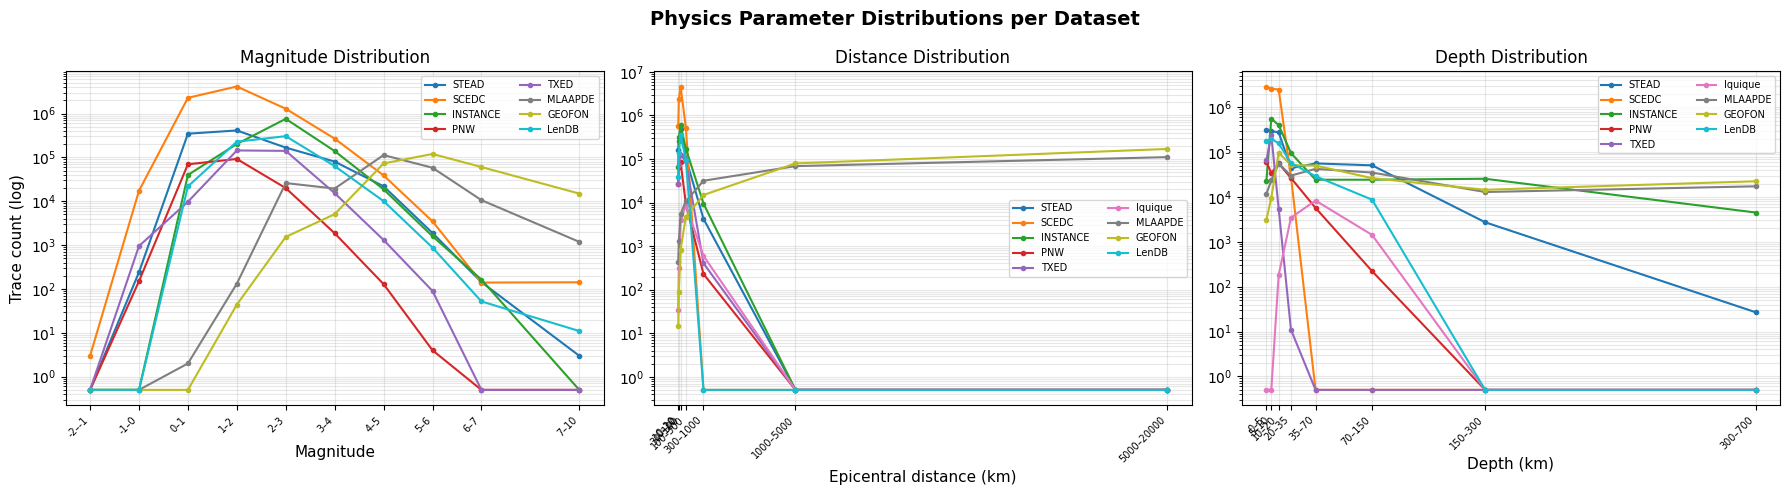

Saved → physics_distributions.png


In [9]:
# ── 1.4 — Physics Parameter Distribution Plots ─────────────────────────────
# Visualise the magnitude, distance, and depth distributions across all
# datasets so coverage gaps are immediately visible.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DS_ORDER = ['stead', 'scedc', 'instancecounts', 'pnw', 'txed',
            'obst2024', 'iquique', 'mlaapde', 'geofon', 'lendb']
DS_LABELS = ['STEAD', 'SCEDC', 'INSTANCE', 'PNW', 'TXED',
             'OBST2024', 'Iquique', 'MLAAPDE', 'GEOFON', 'LenDB']
COLORS = plt.cm.tab10.colors

# Bin-centre helpers
def centres(edges): return [(edges[i]+edges[i+1])/2 for i in range(len(edges)-1)]
mag_centres   = centres(mag_bins)
depth_centres = centres(depth_bins)
dist_centres  = centres(dist_bins)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Physics Parameter Distributions per Dataset', fontsize=14, fontweight='bold')

ax_mag, ax_dist, ax_depth = axes

for idx, (ds, label) in enumerate(zip(DS_ORDER, DS_LABELS)):
    if ds not in results:
        continue
    r = results[ds]
    color = COLORS[idx % len(COLORS)]

    # Magnitude
    if any(v > 0 for v in r['mag']):
        ax_mag.semilogy(mag_centres, [max(v, 0.5) for v in r['mag']],
                        marker='o', ms=3, lw=1.5, label=label, color=color)

    # Distance
    if any(v > 0 for v in r['dist']):
        ax_dist.semilogy(dist_centres, [max(v, 0.5) for v in r['dist']],
                         marker='o', ms=3, lw=1.5, label=label, color=color)

    # Depth
    if any(v > 0 for v in r['depth']):
        ax_depth.semilogy(depth_centres, [max(v, 0.5) for v in r['depth']],
                          marker='o', ms=3, lw=1.5, label=label, color=color)

# Format axes
ax_mag.set_xlabel('Magnitude', fontsize=11)
ax_mag.set_ylabel('Trace count (log)', fontsize=11)
ax_mag.set_title('Magnitude Distribution')
ax_mag.set_xticks(mag_centres)
ax_mag.set_xticklabels([f'{b}–{mag_bins[i+1]}' for i, b in enumerate(mag_bins[:-1])],
                        rotation=45, ha='right', fontsize=7)
ax_mag.legend(fontsize=7, ncol=2)

ax_dist.set_xlabel('Epicentral distance (km)', fontsize=11)
ax_dist.set_title('Distance Distribution')
ax_dist.set_xticks(dist_centres)
ax_dist.set_xticklabels([f'{b}–{dist_bins[i+1]}' for i, b in enumerate(dist_bins[:-1])],
                         rotation=45, ha='right', fontsize=7)
ax_dist.legend(fontsize=7, ncol=2)

ax_depth.set_xlabel('Depth (km)', fontsize=11)
ax_depth.set_title('Depth Distribution')
ax_depth.set_xticks(depth_centres)
ax_depth.set_xticklabels([f'{b}–{depth_bins[i+1]}' for i, b in enumerate(depth_bins[:-1])],
                          rotation=45, ha='right', fontsize=7)
ax_depth.legend(fontsize=7, ncol=2)

for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

plt.tight_layout()
plt.savefig('physics_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → physics_distributions.png')


stead               :  1,030,231 valid S-P pairs
scedc               :  3,781,792 valid S-P pairs
instancecounts      :    713,875 valid S-P pairs
pnw                 :    183,909 valid S-P pairs
txed                :    312,224 valid S-P pairs
obst2024            :     35,384 valid S-P pairs
iquique             :     11,288 valid S-P pairs
mlaapde             :      1,462 valid S-P pairs


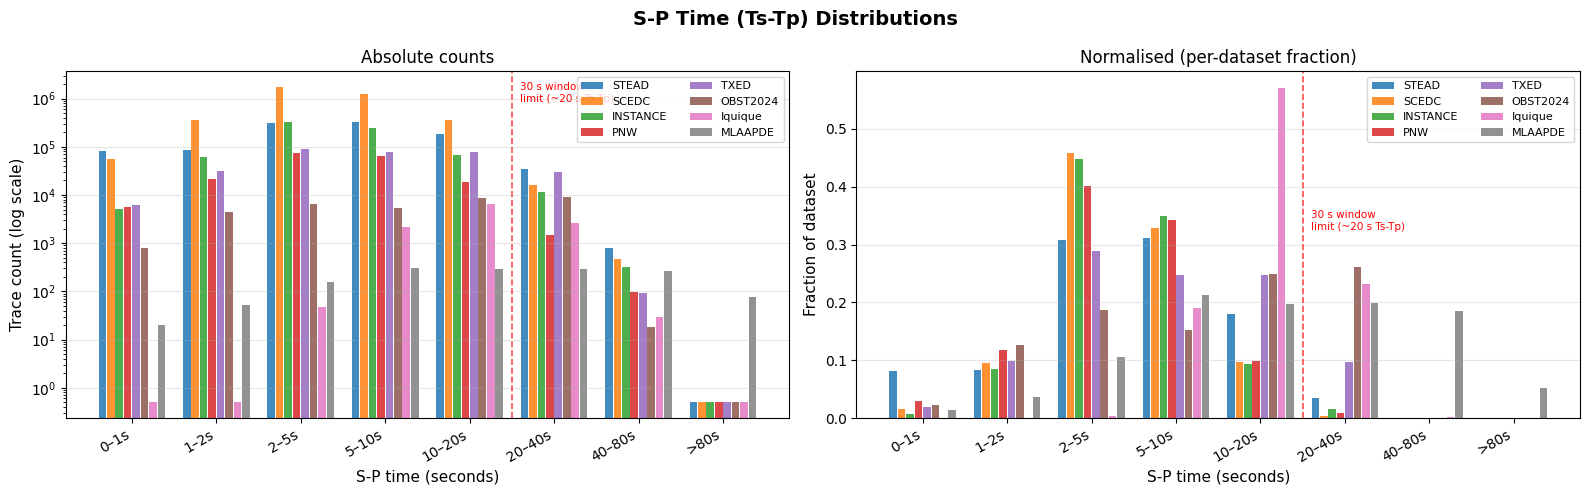

Saved → sp_time_distributions.png

Dataset               median Ts-Tp   % within 20s    % >20s
------------------------------------------------------------
STEAD                        5–10s          96.5%      3.5%
SCEDC                         2–5s          99.6%      0.4%
INSTANCE                      2–5s          98.3%      1.7%
PNW                           2–5s          99.1%      0.9%
TXED                         5–10s          90.3%      9.7%
OBST2024                    10–20s          73.8%     26.2%
Iquique                     10–20s          76.5%     23.5%
MLAAPDE                     10–20s          56.6%     43.4%


In [10]:
# ── 1.4b — S-P Time (Ts-Tp) Distributions ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pathlib import Path

# ── Dataset config: p_col, s_col, sr_col, p_fallbacks, s_fallbacks ──────────
SP_DATASETS = {
    'stead':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': None,                       'p_fb': [], 's_fb': []},
    'scedc':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': 'trace_sampling_rate_hz',   'p_fb': [], 's_fb': []},
    'instancecounts': {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': None,                       'p_fb': [], 's_fb': []},
    'pnw':            {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': 'trace_sampling_rate_hz',   'p_fb': [], 's_fb': []},
    'txed':           {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': None,                       'p_fb': [], 's_fb': []},
    'obst2024':       {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': 'trace_sampling_rate_hz',   'p_fb': [], 's_fb': []},
    'iquique':        {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': 'trace_sampling_rate_hz',   'p_fb': [], 's_fb': []},
    'mlaapde':        {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': 'trace_sampling_rate_hz',
                       'p_fb': ['trace_Pn_arrival_sample', 'trace_Pg_arrival_sample'],
                       's_fb': ['trace_Sn_arrival_sample', 'trace_Sg_arrival_sample']},
    # geofon and lendb excluded: <1% and 0% S picks respectively
}

SP_EDGES   = [0, 1, 2, 5, 10, 20, 40, 80, 200]
SP_LABELS  = ['0–1s', '1–2s', '2–5s', '5–10s', '10–20s', '20–40s', '40–80s', '>80s']
DEFAULT_SR = 100.0

def get_meta_files(name):
    ds_dir = CACHE / name
    single = ds_dir / "metadata.csv"
    if single.exists():
        return [single]
    return sorted([f for f in ds_dir.glob("metadata_*.csv")
                   if not f.name.endswith(".partial")])

sp_results = {}

for ds_name, cfg in SP_DATASETS.items():
    files = get_meta_files(ds_name)
    if not files:
        print(f'SKIP {ds_name}: no metadata found')
        continue

    counts  = np.zeros(len(SP_EDGES) - 1, dtype=np.int64)
    n_valid = 0

    for meta_path in files:
        all_cols = set(pd.read_csv(meta_path, nrows=0).columns)

        # All columns we want to load — primary + fallbacks + SR
        wanted = ([cfg['p']] + cfg['p_fb'] +
                  [cfg['s']] + cfg['s_fb'] +
                  ([cfg['sr']] if cfg['sr'] else []))
        usecols = [c for c in wanted if c in all_cols]

        # Must have at least one P and one S column
        has_p = cfg['p'] in all_cols or any(c in all_cols for c in cfg['p_fb'])
        has_s = cfg['s'] in all_cols or any(c in all_cols for c in cfg['s_fb'])
        if not has_p or not has_s:
            continue

        for chunk in pd.read_csv(meta_path, usecols=usecols,
                                 chunksize=200_000, low_memory=False):
            # Coalesce P: primary first, then fallbacks
            p_series = chunk.get(cfg['p'], pd.Series(dtype=float))
            for fb in cfg['p_fb']:
                if fb in chunk.columns:
                    p_series = p_series.fillna(chunk[fb])

            # Coalesce S: primary first, then fallbacks
            s_series = chunk.get(cfg['s'], pd.Series(dtype=float))
            for fb in cfg['s_fb']:
                if fb in chunk.columns:
                    s_series = s_series.fillna(chunk[fb])

            mask  = p_series.notna() & s_series.notna()
            p_arr = p_series[mask].values
            s_arr = s_series[mask].values

            if len(p_arr) == 0:
                continue

            if cfg['sr'] and cfg['sr'] in chunk.columns:
                sr = chunk.loc[mask, cfg['sr']].fillna(DEFAULT_SR).clip(lower=1).values
            else:
                sr = np.full(len(p_arr), DEFAULT_SR)

            sp = (s_arr - p_arr) / sr
            sp = sp[np.isfinite(sp) & (sp > 0)]
            counts  += np.histogram(sp, bins=SP_EDGES)[0]
            n_valid += len(sp)

    sp_results[ds_name] = counts
    print(f'{ds_name:20s}: {n_valid:>10,} valid S-P pairs')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('S-P Time (Ts-Tp) Distributions', fontsize=14, fontweight='bold')

ax_log, ax_frac = axes
x     = np.arange(len(SP_LABELS))
width = 0.8 / len(sp_results)
COLORS = plt.cm.tab10.colors

DS_DISPLAY = {'stead':'STEAD','scedc':'SCEDC','instancecounts':'INSTANCE',
              'pnw':'PNW','txed':'TXED','obst2024':'OBST2024',
              'iquique':'Iquique','mlaapde':'MLAAPDE'}

for idx, (ds, counts) in enumerate(sp_results.items()):
    offset = (idx - len(sp_results)/2 + 0.5) * width
    label  = DS_DISPLAY.get(ds, ds)
    color  = COLORS[idx % len(COLORS)]
    ax_log.bar(x + offset, np.maximum(counts, 0.5), width=width*0.9,
               label=label, color=color, alpha=0.85)
    total = counts.sum()
    if total > 0:
        ax_frac.bar(x + offset, counts / total, width=width*0.9,
                    label=label, color=color, alpha=0.85)

ax_log.set_yscale('log')
ax_log.set_ylabel('Trace count (log scale)', fontsize=11)
ax_log.set_title('Absolute counts')
ax_frac.set_ylabel('Fraction of dataset', fontsize=11)
ax_frac.set_title('Normalised (per-dataset fraction)')

for ax in axes:
    ax.set_xlabel('S-P time (seconds)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(SP_LABELS, rotation=30, ha='right')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, axis='y', alpha=0.3)
    ax.axvline(x=SP_LABELS.index('10–20s') + 0.5, color='red',
               linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(SP_LABELS.index('10–20s') + 0.6, ax.get_ylim()[1]*0.6,
            '30 s window\nlimit (~20 s Ts-Tp)', color='red', fontsize=7.5, va='top')

plt.tight_layout()
plt.savefig('sp_time_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → sp_time_distributions.png')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Dataset':20s}  {'median Ts-Tp':>12s}  {'% within 20s':>13s}  {'% >20s':>8s}")
print('-' * 60)
for ds, counts in sp_results.items():
    total = counts.sum()
    if total == 0: continue
    cumsum     = np.cumsum(counts)
    median_bin = SP_LABELS[np.searchsorted(cumsum, total/2)]
    within_20  = counts[:5].sum() / total * 100
    beyond_20  = counts[5:].sum() / total * 100
    print(f"{DS_DISPLAY.get(ds,ds):20s}  {median_bin:>12s}  {within_20:>12.1f}%  {beyond_20:>7.1f}%")

### Key observations from distributions

- **Magnitude < 1:** Dominated by SCEDC (2.3M traces). Without SCEDC, small events are severely underrepresented. Gutenberg-Richter weighting in Section 1.5 corrects for this within each magnitude bin.
- **Depth > 70 km:** Comes almost entirely from INSTANCE, GEOFON, and STEAD. Deep seismicity is rare in all regional catalogs — subduction zones and MLAAPDE are the main sources.
- **Distance > 1500 km:** Covered by MLAAPDE (228K traces, mostly local due to full distance range in catalog) and GEOFON (170K traces, primarily teleseismic). GEOFON is excluded from the benchmark due to <1% S picks. MLAAPDE contributes 169,160 teleseismic traces to the benchmark pool after filtering.
- **GEOFON is primarily teleseismic:** Despite being labelled 'broadband', ~170K of 275K GEOFON traces are at >5,000 km. Its S-pick rate of 0.9% makes it unsuitable for a P+S benchmark.
- **OBST2024:** Has P+S picks but no physics metadata (magnitude, depth, distance all NaN) — treated as a flat 400-trace specialty sample rather than stratified into physics bins.
- **MLAAPDE resolves the teleseismic gap:** Earlier versions of this notebook had zero teleseismic traces because NEIC lacked depth metadata and GEOFON lacked S picks. MLAAPDE provides full 3-axis physics metadata (depth available, distance available) enabling proper stratification. The 1,350 teleseismic traces in the final benchmark come entirely from MLAAPDE.


<a id='1.4b'></a>
## 1.4b Label Quality Filtering

Alberto Aguilar (labelerrors, 2024) identified pervasive label errors in several SeisBench datasets using confident learning — traces where a trained model is systematically more confident in a different pick than the assigned label. Traces flagged as bad labels are excluded from both the benchmark and any future training sets.

**Bad label counts from Ardid's analysis:**

| Dataset | Bad labels excluded | % of dataset |
|---------|-------------------|-------------|
| INSTANCE | 92,561 | 8.0% |
| PNW | 4,970 | 2.7% |
| TXED | 4,672 | 0.9% |
| STEAD | 149 | 0.01% |

Datasets not yet analysed by Ardid: SCEDC, MLAAPDE, GEOFON, LenDB, OBST2024. These are included without bad-label filtering — a known limitation to note in the methods section.


In [11]:
from pathlib import Path
import pandas as pd

# ── UPDATE this path to wherever you saved the Alberto Ardid CSVs ──
LABEL_ERROR_DIR = Path('../data/labelerrors/')

REPORT_MAP = {
    'stead_report':    'stead',
    'instance_report': 'instancecounts',   # SeisBench name differs from report stem
    'pnw_report':      'pnw',
    'txed_report':     'txed',
    'iquique_report':  'iquique',
    'ethz_report':     'ethz',
}

bad_traces = {}   # ds_name  →  set of bad trace_name strings

for stem, ds_name in REPORT_MAP.items():
    fpath = LABEL_ERROR_DIR / f'{stem}.csv'
    if not fpath.exists():
        print(f'MISSING  {fpath}')
        continue
    df_bad = pd.read_csv(fpath, usecols=['trace_name'])
    bad_traces[ds_name] = set(df_bad['trace_name'])
    print(f'{ds_name:20s}  bad traces flagged: {len(bad_traces[ds_name]):>7,}')

print(f'\nTotal bad traces across all datasets: {sum(len(v) for v in bad_traces.values()):,}')
print('No report available for: scedc, neic, geofon, lendb, obst2024')

stead                 bad traces flagged:     149
instancecounts        bad traces flagged:  92,561
pnw                   bad traces flagged:   4,970
txed                  bad traces flagged:   4,672
iquique               bad traces flagged:     515
ethz                  bad traces flagged:     895

Total bad traces across all datasets: 103,762
No report available for: scedc, neic, geofon, lendb, obst2024


<a id='1.5'></a>
## 1.5 Benchmark Construction

Build a physics-stratified benchmark from 8 datasets covering local, regional, and teleseismic distances, with seismologically motivated bins across depth and magnitude.

### Design decisions

| Decision | Rationale |
|---|---|
| **P or S (not strictly both required)** | MLAAPDE teleseismic traces are almost entirely P-only — this is physically expected, not a data problem. P-recall and S-recall are evaluated separately. |
| **Exclude Aguilar bad labels** | Mislabeled test traces penalise correct model predictions and inflate apparent error rates |
| **Ts–Tp stored as diagnostic** | S-P time directly determines P–S separation in the 30 s waveform window; values >20 s mean S may exit the PhaseNet input window |
| **G-R weighted within-bin sampling** | Seismicity follows log₁₀N = a − bM (b≈1); flat sampling overrepresents large events by orders of magnitude |
| **Tectonic type tag** | Enables post-hoc breakdown by tectonic regime |

### Physics bins

| Axis | Bins | Coverage |
|---|---|---|
| **Distance** | local <150 km · regional 150–1500 km · teleseismic >1500 km | All three strata filled (1,420 / 1,306 / 1,350) |
| **Depth** | 0–15 · 15–70 · 70–300 · >300 km | All four strata filled |
| **Magnitude** | M < 3 · M 3–6 · M > 6 | All three strata filled |
| **Ts–Tp** | Stored per trace; not a sampling axis | Diagnostic only |

3 × 4 × 3 = 36 physics bins · target 150 traces/bin · cap 80 traces/dataset/bin.

### Dataset-specific handling

| Dataset | Handling | Reason |
|---|---|---|
| STEAD, SCEDC, INSTANCE, PNW, TXED | Full 3-axis physics bins | Complete metadata available |
| **MLAAPDE** | Teleseismic only · flat 1,350-trace G-R weighted sample · P-only acceptable | Supersedes NEIC; native 40 Hz (resampled in Step 2); multiple phase columns coalesced (P→Pn→Pg, S→Sn→Sg); sharded by month |
| Iquique | Distance × depth bins · no magnitude | No magnitude column in metadata |
| OBST2024 | Flat 400-trace sample · no physics bins | No physics metadata (depth, distance, magnitude all NaN) |
| GEOFON | **Excluded** | <1% S picks |
| LenDB | **Excluded** | P-only (no S arrival column) |

### MLAAPDE teleseismic rationale

MLAAPDE supersedes the NEIC dataset in SeisBench. It provides:
- Full timestamps (`trace_start_time`) enabling FDSN waveform retrieval
- `source_depth_km` enabling full 3-axis physics binning
- Network/station/channel metadata
- 228,256 traces covering July 2013 – October 2014 across 16 monthly files
- 169,160 traces at teleseismic distances (>1,500 km) available for sampling

The 0.6% P+S co-occurrence rate is physically expected at teleseismic distances — S picking is not routine in global P-phase catalogs. The benchmark includes P-only MLAAPDE traces and evaluates P-recall and S-recall in separate splits.


In [12]:
def safe_usecols(meta_path, wanted):
    """Return only columns from `wanted` that exist in the CSV header."""
    existing = set(pd.read_csv(meta_path, nrows=0).columns)
    return [c for c in wanted if c in existing]


# ============================================================
# 1.5  Benchmark Construction  —  clean master script
# Run this cell to produce benchmark_manifest.csv
# Prerequisites: CACHE defined (Cell 1), haversine_km defined (Cell 13),
#               bad_traces dict defined (Cell 1.4b)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ── Configuration ─────────────────────────────────────────
TARGET_PER_BIN            = 150
MAX_PER_DATASET_PER_BIN   = 80
OBST2024_FLAT_SAMPLE      = 400
IQUIQUE_TARGET_PER_BIN    = 80
MLAAPDE_TELESEISMIC_TOTAL = 1350  # ~equal to local + regional strata
RANDOM_SEED               = 42
GR_B_VALUE                = 1.0   # Gutenberg-Richter b-value for within-bin weighting

DIST_EDGES  = [0,   150,  1500, np.inf]
DIST_LABELS = ['local (<150km)', 'regional (150-1500km)', 'teleseismic (>1500km)']

DEPTH_EDGES  = [0,  15,  70,  300, np.inf]
DEPTH_LABELS = ['upper-crustal (0-15km)', 'lower-crust (15-70km)',
                'intermediate (70-300km)', 'deep-focus (>300km)']

MAG_EDGES  = [-np.inf, 3.0, 6.0, np.inf]
MAG_LABELS = ['micro (M<3)', 'moderate (M3-6)', 'large (M>6)']

# ── Dataset configurations ────────────────────────────────
# geofon and lendb removed: <1% and 0% S picks respectively.
# Requiring both P and S would leave essentially nothing.
FULL_DATASETS = {
    'stead': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'source_distance_km',
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'global_mixed',
        'region': 'Global (US-heavy)', 'trained_models': ['stead'],
    },
    'scedc': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'station_epicentral_distance',
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'transform',
        'region': 'Southern California', 'trained_models': ['scedc'],
    },
    'instancecounts': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km',
        'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'subduction_crustal',
        'region': 'Italy / Mediterranean', 'trained_models': ['instance'],
    },
    'pnw': {
        'mag': 'preferred_source_magnitude', 'depth': 'source_depth_km', 'dist': None,
        'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': True, 'tectonic_type': 'subduction',
        'region': 'Pacific Northwest / Cascadia', 'trained_models': [],
    },
    'txed': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None,
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': True, 'tectonic_type': 'induced',
        'region': 'Texas (induced seismicity)', 'trained_models': [],
    },
}

# ── Helper functions ──────────────────────────────────────

def assign_bins(series, edges, labels):
    return pd.cut(series, bins=edges, labels=labels, right=False, include_lowest=True)

def gr_weight(magnitude_series, b=GR_B_VALUE):
    """
    Gutenberg-Richter inverse weight: 10^(-b*M).
    Smaller-magnitude events are proportionally more common in nature;
    this weight corrects for flat sampling within a magnitude bin.
    Weights are normalised to sum to 1 within each call.
    """
    w = np.power(10.0, -b * magnitude_series.values)
    w = np.where(np.isfinite(w), w, 1.0)
    return w / w.sum()

def load_and_filter(meta_path, usecols, p_col, s_col, bad_set,
                    chunksize=500_000, require_s=True):
    """
    Load metadata CSV in chunks, keeping only traces that:
      - have a valid P pick
      - have a valid S pick  (if require_s=True; set False for P-only datasets like MLAAPDE)
      - are not in Alberto's bad set  (label quality filter)
    Returns a concatenated DataFrame, or None if nothing survives.
    """
    chunks = []
    for chunk in pd.read_csv(meta_path, usecols=usecols, chunksize=chunksize, low_memory=False):
        mask = chunk[p_col].notna()
        if require_s and s_col in chunk.columns:
            mask = mask & chunk[s_col].notna()
        chunk = chunk[mask]
        if bad_set and 'trace_name' in chunk.columns:
            chunk = chunk[~chunk['trace_name'].isin(bad_set)]
        if len(chunk) > 0:
            chunks.append(chunk)
    return pd.concat(chunks, ignore_index=False) if chunks else None


# ── Process FULL_DATASETS ─────────────────────────────────
full_traces = []

for ds_name, cfg in FULL_DATASETS.items():
    meta_path = CACHE / ds_name / 'metadata.csv'
    if not meta_path.exists():
        print(f'SKIP {ds_name}: no metadata.csv')
        continue

    all_cols = set(pd.read_csv(meta_path, nrows=0).columns)
    sr_col   = cfg['sr'] if cfg['sr'] in all_cols else None
    usecols  = ['trace_name', cfg['p'], cfg['s'], cfg['mag'], cfg['depth']]
    if sr_col:
        usecols.append(sr_col)
    if cfg['dist']:
        usecols.append(cfg['dist'])
    if cfg['compute_dist']:
        usecols += ['source_latitude_deg', 'source_longitude_deg',
                    'station_latitude_deg', 'station_longitude_deg']
    usecols = list(dict.fromkeys(usecols))

    print(f'Reading {ds_name}...', end=' ', flush=True)
    raw = load_and_filter(
        meta_path, usecols,
        p_col   = cfg['p'],
        s_col   = cfg['s'],
        bad_set = bad_traces.get(ds_name, set()),
    )
    if raw is None:
        print('no valid traces after filtering'); continue

    n_raw = len(raw)
    n_bad = len(bad_traces.get(ds_name, set()))

    out = pd.DataFrame()
    out['trace_name']       = raw['trace_name'].values
    out['source_month']     = None
    out['original_index']   = raw.index.values
    out['magnitude']        = raw[cfg['mag']].values
    out['depth_km']         = raw[cfg['depth']].values
    out['p_arrival_sample'] = raw[cfg['p']].values
    out['s_arrival_sample'] = raw[cfg['s']].values
    out['has_s_pick']       = True

    if cfg['compute_dist']:
        out['distance_km'] = haversine_km(
            raw['source_latitude_deg'].values, raw['source_longitude_deg'].values,
            raw['station_latitude_deg'].values, raw['station_longitude_deg'].values,
        )
    else:
        out['distance_km'] = raw[cfg['dist']].values

    if sr_col and sr_col in raw.columns:
        sr = raw[sr_col].values
    else:
        sr = np.full(len(raw), 100.0)
        print(f'  [{ds_name}] trace_sampling_rate_hz not found — defaulting to 100 Hz')
    out['ts_tp_s'] = np.where(
        (sr > 0) & np.isfinite(sr),
        (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr,
        np.nan,
    )

    out['gr_weight'] = np.where(
        out['magnitude'].notna(),
        np.power(10.0, -GR_B_VALUE * out['magnitude'].values),
        1.0,
    )

    out['dist_bin']  = assign_bins(out['distance_km'], DIST_EDGES,  DIST_LABELS)
    out['depth_bin'] = assign_bins(out['depth_km'],    DEPTH_EDGES, DEPTH_LABELS)
    out['mag_bin']   = assign_bins(out['magnitude'],   MAG_EDGES,   MAG_LABELS)

    fully_binned = out['dist_bin'].notna() & out['depth_bin'].notna() & out['mag_bin'].notna()
    out['physics_bin'] = np.where(
        fully_binned,
        out['dist_bin'].astype(str) + ' | ' + out['depth_bin'].astype(str) + ' | ' + out['mag_bin'].astype(str),
        'partial',
    )

    out['dataset']        = ds_name
    out['tectonic_type']  = cfg['tectonic_type']
    out['region']         = cfg['region']
    out['trained_models'] = ','.join(cfg['trained_models'])

    n_binned = fully_binned.sum()
    print(f'{n_raw:,} kept (of those, {n_bad:,} bad labels excluded) | {n_binned:,} fully binned')
    full_traces.append(out[fully_binned])


# ── Process MLAAPDE (teleseismic only) ────────────────────
MLAAPDE_P_COLS    = ['trace_P_arrival_sample', 'trace_Pn_arrival_sample', 'trace_Pg_arrival_sample']
MLAAPDE_S_COLS    = ['trace_S_arrival_sample', 'trace_Sn_arrival_sample', 'trace_Sg_arrival_sample']
MLAAPDE_NATIVE_SR = 40.0

def coalesce_phases(df, col_priority):
    result = pd.Series(np.nan, index=df.index)
    for col in col_priority:
        if col in df.columns:
            result = result.fillna(df[col])
    return result

print('\nReading mlaapde (sharded by month)...')
mlaapde_dir    = CACHE / 'mlaapde'
monthly_files  = sorted([f for f in mlaapde_dir.glob('metadata_*.csv')
                          if not f.name.endswith('.partial')])
mlaapde_traces = None

if not monthly_files:
    print('No complete MLAAPDE monthly files found in cache.')
else:
    chunks = []
    for meta_file in monthly_files:
        month = meta_file.stem.split('_')[1]
        df    = pd.read_csv(meta_file, low_memory=False)

        df['p_arrival_sample'] = coalesce_phases(df, MLAAPDE_P_COLS)
        df['s_arrival_sample'] = coalesce_phases(df, MLAAPDE_S_COLS)

        # ── CHANGED: keep traces with P, S, or both ───────────────────────
        has_p = df['p_arrival_sample'].notna()
        has_s = df['s_arrival_sample'].notna()
        df    = df[has_p | has_s].copy()
        # ──────────────────────────────────────────────────────────────────
        if len(df) == 0:
            continue

        out = pd.DataFrame()
        out['trace_name']       = df['trace_name'].values
        out['source_month']     = month
        out['original_index']   = df.index.values
        out['magnitude']        = df['source_magnitude'].values    if 'source_magnitude'    in df.columns else np.nan
        out['depth_km']         = df['source_depth_km'].values     if 'source_depth_km'     in df.columns else np.nan
        out['distance_km']      = df['path_ep_distance_km'].values if 'path_ep_distance_km' in df.columns else np.nan
        out['p_arrival_sample'] = df['p_arrival_sample'].values
        out['s_arrival_sample'] = df['s_arrival_sample'].values

        # ── CHANGED: track P and S availability separately ────────────────
        out['has_p_pick'] = out['p_arrival_sample'].notna()
        out['has_s_pick'] = out['s_arrival_sample'].notna()
        # ──────────────────────────────────────────────────────────────────

        # ts_tp_s only meaningful when both picks present
        out['ts_tp_s'] = np.where(
            out['has_p_pick'] & out['has_s_pick'],
            (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / MLAAPDE_NATIVE_SR,
            np.nan)

        out['gr_weight'] = np.power(10.0, -GR_B_VALUE * out['magnitude'].fillna(0).values)
        out['dist_bin']  = assign_bins(out['distance_km'], DIST_EDGES, DIST_LABELS)
        out['mag_bin']   = assign_bins(out['magnitude'],   MAG_EDGES,  MAG_LABELS)
        has_depth        = out['depth_km'].notna()
        out['depth_bin'] = np.where(
            has_depth,
            assign_bins(out['depth_km'], DEPTH_EDGES, DEPTH_LABELS),
            np.nan)

        tele_mask = out['dist_bin'] == 'teleseismic (>1500km)'
        valid     = tele_mask & out['mag_bin'].notna()
        depth_str = np.where(has_depth & valid, out['depth_bin'].astype(str), 'depth_unknown')

        out['physics_bin']    = np.where(
            valid,
            'teleseismic (>1500km) | ' + depth_str + ' | ' + out['mag_bin'].astype(str),
            'unusable')
        out['dataset']        = 'mlaapde'
        out['tectonic_type']  = 'global_teleseismic'
        out['region']         = 'Global (teleseismic)'
        out['trained_models'] = 'neic'

        chunks.append(out[valid].copy())

    if chunks:
        mlaapde_traces = pd.concat(chunks, ignore_index=True)
        n_total  = len(mlaapde_traces)
        n_p_only = (mlaapde_traces['has_p_pick'] & ~mlaapde_traces['has_s_pick']).sum()
        n_s_only = (~mlaapde_traces['has_p_pick'] & mlaapde_traces['has_s_pick']).sum()
        n_both   = (mlaapde_traces['has_p_pick'] & mlaapde_traces['has_s_pick']).sum()
        print(f'  {len(monthly_files)} monthly files | {n_total:,} teleseismic traces')
        print(f'  P+S: {n_both:,}  |  P-only: {n_p_only:,}  |  S-only: {n_s_only:,}')
        print(f'  Physics bins: {mlaapde_traces["physics_bin"].nunique()} unique')
    else:
        print('No teleseismic MLAAPDE traces found across monthly files.')


# ── Process Iquique (distance × depth, no magnitude) ─────
print('Reading iquique...', end=' ', flush=True)
iq_path   = CACHE / 'iquique' / 'metadata.csv'
iq_traces = None
if iq_path.exists():
    iq_usecols = safe_usecols(iq_path, ['trace_name', 'trace_P_arrival_sample',
                  'trace_S_arrival_sample', 'source_depth_km', 'trace_sampling_rate_hz',
                  'source_latitude_deg', 'source_longitude_deg',
                  'station_latitude_deg', 'station_longitude_deg'])
    raw = load_and_filter(iq_path, iq_usecols,
                          'trace_P_arrival_sample', 'trace_S_arrival_sample',
                          bad_set=bad_traces.get('iquique', set()))
    if raw is not None:
        out = pd.DataFrame()
        out['trace_name']       = raw['trace_name'].values
        out['source_month']     = None
        out['original_index']   = raw.index.values
        out['magnitude']        = np.nan
        out['depth_km']         = raw['source_depth_km'].values
        out['distance_km']      = haversine_km(
            raw['source_latitude_deg'].values, raw['source_longitude_deg'].values,
            raw['station_latitude_deg'].values, raw['station_longitude_deg'].values)
        out['p_arrival_sample'] = raw['trace_P_arrival_sample'].values
        out['s_arrival_sample'] = raw['trace_S_arrival_sample'].values
        out['has_s_pick']       = True
        sr = (raw['trace_sampling_rate_hz'].values
              if 'trace_sampling_rate_hz' in raw.columns else np.full(len(raw), 100.0))
        out['ts_tp_s']   = np.where((sr > 0) & np.isfinite(sr),
                            (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr, np.nan)
        out['gr_weight'] = 1.0
        out['dist_bin']  = assign_bins(out['distance_km'], DIST_EDGES,  DIST_LABELS)
        out['depth_bin'] = assign_bins(out['depth_km'],    DEPTH_EDGES, DEPTH_LABELS)
        out['mag_bin']   = np.nan
        valid = out['dist_bin'].notna() & out['depth_bin'].notna()
        out['physics_bin']    = np.where(valid,
            out['dist_bin'].astype(str) + ' | ' + out['depth_bin'].astype(str) + ' | mag_unknown',
            'unusable')
        out['dataset']        = 'iquique'
        out['tectonic_type']  = 'subduction_aftershock'
        out['region']         = 'Northern Chile'
        out['trained_models'] = 'iquique'
        iq_traces = out[valid]
        print(f'{len(raw):,} kept | {valid.sum():,} binned (dist × depth, no mag)')


# ── Process OBST2024 (flat sample, no physics metadata) ──
print('Reading obst2024...', end=' ', flush=True)
obst_path   = CACHE / 'obst2024' / 'metadata.csv'
obst_traces = None
if obst_path.exists():
    obs_usecols = safe_usecols(obst_path, ['trace_name', 'trace_p_arrival_sample',
                   'trace_s_arrival_sample', 'trace_sampling_rate_hz'])
    raw = load_and_filter(obst_path, obs_usecols,
                          p_col='trace_p_arrival_sample', s_col='trace_s_arrival_sample',
                          bad_set=bad_traces.get('obst2024', set()))
    if raw is not None:
        out = pd.DataFrame()
        out['trace_name']       = raw['trace_name'].values
        out['source_month']     = None
        out['original_index']   = raw.index.values
        for col in ['magnitude', 'depth_km', 'distance_km']:
            out[col] = np.nan
        out['p_arrival_sample'] = raw['trace_p_arrival_sample'].values
        out['s_arrival_sample'] = raw['trace_s_arrival_sample'].values
        out['has_s_pick']       = True
        sr = (raw['trace_sampling_rate_hz'].values
              if 'trace_sampling_rate_hz' in raw.columns else np.full(len(raw), 100.0))
        out['ts_tp_s']   = np.where((sr > 0) & np.isfinite(sr),
                            (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr, np.nan)
        out['gr_weight'] = 1.0
        for col in ['dist_bin', 'depth_bin', 'mag_bin']:
            out[col] = np.nan
        out['physics_bin']    = 'OBS_flat'
        out['dataset']        = 'obst2024'
        out['tectonic_type']  = 'ocean_bottom'
        out['region']         = 'East Pacific Rise (OBS)'
        out['trained_models'] = 'obs'
        obst_traces = out
        print(f'{len(out):,} valid traces (flat sample, no physics binning)')

Reading stead...   [stead] trace_sampling_rate_hz not found — defaulting to 100 Hz
1,030,082 kept (of those, 149 bad labels excluded) | 1,023,138 fully binned
Reading scedc... 3,783,102 kept (of those, 0 bad labels excluded) | 3,727,167 fully binned
Reading instancecounts...   [instancecounts] trace_sampling_rate_hz not found — defaulting to 100 Hz
631,167 kept (of those, 92,561 bad labels excluded) | 631,167 fully binned
Reading pnw... 178,939 kept (of those, 4,970 bad labels excluded) | 154,552 fully binned
Reading txed...   [txed] trace_sampling_rate_hz not found — defaulting to 100 Hz
307,559 kept (of those, 4,672 bad labels excluded) | 307,219 fully binned

Reading mlaapde (sharded by month)...
  16 monthly files | 169,160 teleseismic traces
  P+S: 6  |  P-only: 169,137  |  S-only: 17
  Physics bins: 11 unique
Reading iquique... 10,798 kept | 10,798 binned (dist × depth, no mag)
Reading obst2024... 35,394 valid traces (flat sample, no physics binning)


In [13]:
# ── Stratified sampling with Gutenberg-Richter weighting ──
rng     = np.random.RandomState(RANDOM_SEED)
sampled = []

# A. Full 3-axis bins (stead, scedc, instancecounts, pnw, txed)
if full_traces:
    full_pool = pd.concat(full_traces, ignore_index=True)
    for bin_name, group in full_pool.groupby('physics_bin'):
        bin_samples = []
        for ds_name, ds_group in group.groupby('dataset'):
            n = min(MAX_PER_DATASET_PER_BIN, len(ds_group))
            w = ds_group['gr_weight'].values
            w = w / w.sum()
            bin_samples.append(ds_group.sample(n=n, weights=w, random_state=rng))
        bin_df = pd.concat(bin_samples)
        if len(bin_df) > TARGET_PER_BIN:
            w = bin_df['gr_weight'].values
            w = w / w.sum()
            bin_df = bin_df.sample(n=TARGET_PER_BIN, weights=w, random_state=rng)
        sampled.append(bin_df)
    print(f"Full 3-axis bins: {sum(len(s) for s in sampled):,} traces")

# B. MLAAPDE teleseismic
# Most traces are P-only (expected for teleseismic distances — S is rarely
# picked at >1500 km). G-R weighted sampling across all teleseismic mag bins.
if mlaapde_traces is not None:
    n_mlaapde    = min(MLAAPDE_TELESEISMIC_TOTAL, len(mlaapde_traces))
    w            = mlaapde_traces['gr_weight'].values
    w            = w / w.sum()
    mlaapde_sample = mlaapde_traces.sample(n=n_mlaapde, weights=w, random_state=rng)
    sampled.append(mlaapde_sample)
    n_both   = (mlaapde_sample['has_p_pick'] & mlaapde_sample['has_s_pick']).sum()
    n_p_only = (mlaapde_sample['has_p_pick'] & ~mlaapde_sample['has_s_pick']).sum()
    n_s_only = (~mlaapde_sample['has_p_pick'] & mlaapde_sample['has_s_pick']).sum()
    print(f"MLAAPDE teleseismic: {n_mlaapde:,} traces "
          f"(P+S: {n_both:,} | P-only: {n_p_only:,} | S-only: {n_s_only:,})")

# C. Iquique (distance × depth, no magnitude — flat weights)
if iq_traces is not None:
    iq_count = 0
    for bin_name, group in iq_traces.groupby('physics_bin'):
        n = min(IQUIQUE_TARGET_PER_BIN, len(group))
        sampled.append(group.sample(n=n, random_state=rng))
        iq_count += n
    print(f"Iquique: {iq_count:,} traces across {iq_traces['physics_bin'].nunique()} bins")

# D. OBST2024 (flat — no physics metadata)
if obst_traces is not None:
    n_obs = min(OBST2024_FLAT_SAMPLE, len(obst_traces))
    sampled.append(obst_traces.sample(n=n_obs, random_state=rng))
    print(f"OBST2024: {n_obs:,} traces")

benchmark = pd.concat(sampled, ignore_index=True)

# Fill has_p_pick for non-MLAAPDE datasets (all guaranteed P by load_and_filter)
if 'has_p_pick' not in benchmark.columns:
    benchmark['has_p_pick'] = True
else:
    benchmark['has_p_pick'] = benchmark['has_p_pick'].fillna(True)

print(f"\nTotal benchmark : {len(benchmark):,} traces")
print(f"  has P pick    : {benchmark['has_p_pick'].sum():,}")
print(f"  has S pick    : {benchmark['has_s_pick'].sum():,}")
print(f"  has both P+S  : {(benchmark['has_p_pick'] & benchmark['has_s_pick']).sum():,}")
print(f"  has Ts-Tp     : {benchmark['ts_tp_s'].notna().sum():,}")
print(f"\nBy dataset:")
print(benchmark.groupby('dataset')[['has_p_pick','has_s_pick']].sum().to_string())

Full 3-axis bins: 2,406 traces
MLAAPDE teleseismic: 1,350 traces (P+S: 0 | P-only: 1,349 | S-only: 1)
Iquique: 320 traces across 4 bins
OBST2024: 400 traces

Total benchmark : 4,476 traces
  has P pick    : 4,475
  has S pick    : 3,127
  has both P+S  : 3,126
  has Ts-Tp     : 3,126

By dataset:
                has_p_pick  has_s_pick
dataset                               
instancecounts         845         845
iquique                320         320
mlaapde               1349           1
obst2024               400         400
pnw                    378         378
scedc                  326         326
stead                  672         672
txed                   185         185


/tmp/ipykernel_2736861/264024781.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  benchmark = pd.concat(sampled, ignore_index=True)
/tmp/ipykernel_2736861/264024781.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  benchmark = pd.concat(sampled, ignore_index=True)
/tmp/ipykernel_2736861/264024781.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the

In [14]:
# Save benchmark manifest
output_cols = [
    'dataset', 'trace_name', 'original_index', 'source_month',
    'tectonic_type', 'region', 'trained_models',
    'magnitude', 'depth_km', 'distance_km', 'ts_tp_s',
    'p_arrival_sample', 's_arrival_sample', 'has_p_pick', 'has_s_pick',
    'dist_bin', 'depth_bin', 'mag_bin', 'physics_bin',
]
benchmark[output_cols].to_csv('benchmark_manifest.csv', index=False)
print(f"Saved benchmark_manifest.csv  ({len(benchmark):,} traces)")

Saved benchmark_manifest.csv  (4,476 traces)


<a id='1.6'></a>
## 1.6 Benchmark Summary & Visualisation

Print a complete breakdown of the final benchmark and produce a six-panel diagnostic figure confirming the stratification is balanced and well-distributed.

### Final benchmark at a glance

| Stratum | Traces | Source datasets |
|---------|--------|----------------|
| Local (<150 km) | 1,420 | STEAD, SCEDC, INSTANCE, PNW, TXED |
| Regional (150–1500 km) | 1,306 | STEAD, SCEDC, INSTANCE, PNW, TXED |
| Teleseismic (>1500 km) | 1,350 | MLAAPDE only |
| OBS (flat sample) | 400 | OBST2024 |
| **Total** | **4,476** | **8 datasets** |

### Pick availability

| Category | Count | Evaluation scope |
|----------|-------|-----------------|
| P + S complete | 3,126 | Full P-recall and S-recall |
| P only (MLAAPDE) | 1,349 | P-recall only |
| S only (MLAAPDE) | 1 | S-recall only |

### Ts-Tp note

1,310 traces have Ts-Tp in the 20–50 s range (primarily INSTANCE median 26.6 s and Iquique median 18.2 s). For these traces the S arrival may fall outside PhaseNet's 30 s input window, so S-recall will be lower even for a well-trained model. This is a property of the data, not a benchmark design flaw — it is worth noting in the results section.

### Output file

`benchmark_manifest.csv` — columns: `dataset`, `trace_name`, `original_index`, `source_month`, `tectonic_type`, `region`, `trained_models`, `magnitude`, `depth_km`, `distance_km`, `ts_tp_s`, `p_arrival_sample`, `s_arrival_sample`, `has_p_pick`, `has_s_pick`, `dist_bin`, `depth_bin`, `mag_bin`, `physics_bin`.

The `source_month` column (e.g. `201307`) is used by Step 2 to open the correct MLAAPDE monthly HDF5 file. It is `None` for all non-MLAAPDE datasets.


In [15]:
print(f"Total traces: {len(benchmark):,}")

# has_s_pick is no longer universal — MLAAPDE is mostly P-only
print(f"  Has P pick : {benchmark['has_p_pick'].sum():,}")
print(f"  Has S pick : {benchmark['has_s_pick'].sum():,}")
print(f"  Has both   : {(benchmark['has_p_pick'] & benchmark['has_s_pick']).sum():,}")
print(f"Ts-Tp available: {benchmark['ts_tp_s'].notna().sum():,} / {len(benchmark):,}")

print(f"\n--- By dataset ---")
ds_summary = benchmark.groupby('dataset').agg(
    count        = ('dataset',    'size'),
    n_p          = ('has_p_pick', 'sum'),
    n_s          = ('has_s_pick', 'sum'),
    median_ts_tp = ('ts_tp_s',    'median'),
).sort_values('count', ascending=False)
for idx, row in ds_summary.iterrows():
    ts = f"{row['median_ts_tp']:.1f}s" if pd.notna(row['median_ts_tp']) else "N/A"
    print(f"  {idx:20s}  n={int(row['count']):>5}  "
          f"P={int(row['n_p']):>5}  S={int(row['n_s']):>5}  median Ts-Tp={ts}")

print(f"\n--- By distance ---")
for db in DIST_LABELS:
    print(f"  {db:35s}  {(benchmark['dist_bin'] == db).sum():>5}")
print(f"  {'missing (OBS)':35s}  {benchmark['dist_bin'].isna().sum():>5}")

print(f"\n--- By depth ---")
for db in DEPTH_LABELS:
    print(f"  {db:35s}  {(benchmark['depth_bin'] == db).sum():>5}")
print(f"  {'missing (MLAAPDE no-depth / OBS)':35s}  {benchmark['depth_bin'].isna().sum():>5}")

print(f"\n--- By magnitude ---")
for mb in MAG_LABELS:
    print(f"  {mb:35s}  {(benchmark['mag_bin'] == mb).sum():>5}")
print(f"  {'missing (Iquique + OBS)':35s}  {benchmark['mag_bin'].isna().sum():>5}")

print(f"\n--- Ts-Tp distribution (seconds) ---")
tp_bins   = [0, 2, 5, 10, 20, 50]
tp_labels = ['0-2s', '2-5s', '5-10s', '10-20s', '20-50s', '>50s']
tp_binned = pd.cut(benchmark['ts_tp_s'], bins=tp_bins + [np.inf], labels=tp_labels, right=False)
for lb in tp_labels:
    print(f"  {lb:12s}  {(tp_binned == lb).sum():>5}")
print(f"  {'N/A (P-only or S-only)':12s}  {benchmark['ts_tp_s'].isna().sum():>5}")

print(f"\n--- Fair evaluation usage ---")
print("When evaluating PhaseNet/stead, filter out in-domain traces:")
print("  df[~df['trained_models'].str.contains('stead')]")

print(f"\n--- Pick availability breakdown ---")
n_both   = (benchmark['has_p_pick'] & benchmark['has_s_pick']).sum()
n_p_only = (benchmark['has_p_pick'] & ~benchmark['has_s_pick']).sum()
n_s_only = (~benchmark['has_p_pick'] & benchmark['has_s_pick']).sum()
print(f"  P + S (complete)  : {n_both:,}")
print(f"  P only            : {n_p_only:,}  (MLAAPDE teleseismic)")
print(f"  S only            : {n_s_only:,}  (MLAAPDE teleseismic)")
print(f"\n  P-recall  → evaluate on {benchmark['has_p_pick'].sum():,} traces  (filter: benchmark[benchmark['has_p_pick']])")
print(f"  S-recall  → evaluate on {benchmark['has_s_pick'].sum():,} traces  (filter: benchmark[benchmark['has_s_pick']])")
print(f"  Ts-Tp     → only meaningful on {n_both:,} traces with both picks")

Total traces: 4,476
  Has P pick : 4,475
  Has S pick : 3,127
  Has both   : 3,126
Ts-Tp available: 3,126 / 4,476

--- By dataset ---
  mlaapde               n= 1350  P= 1349  S=    1  median Ts-Tp=N/A
  instancecounts        n=  845  P=  845  S=  845  median Ts-Tp=26.6s
  stead                 n=  672  P=  672  S=  672  median Ts-Tp=17.9s
  obst2024              n=  400  P=  400  S=  400  median Ts-Tp=10.4s
  pnw                   n=  378  P=  378  S=  378  median Ts-Tp=13.9s
  scedc                 n=  326  P=  326  S=  326  median Ts-Tp=9.9s
  iquique               n=  320  P=  320  S=  320  median Ts-Tp=18.2s
  txed                  n=  185  P=  185  S=  185  median Ts-Tp=8.5s

--- By distance ---
  local (<150km)                        1420
  regional (150-1500km)                 1306
  teleseismic (>1500km)                 1350
  missing (OBS)                          400

--- By depth ---
  upper-crustal (0-15km)                1085
  lower-crust (15-70km)                 1349
 

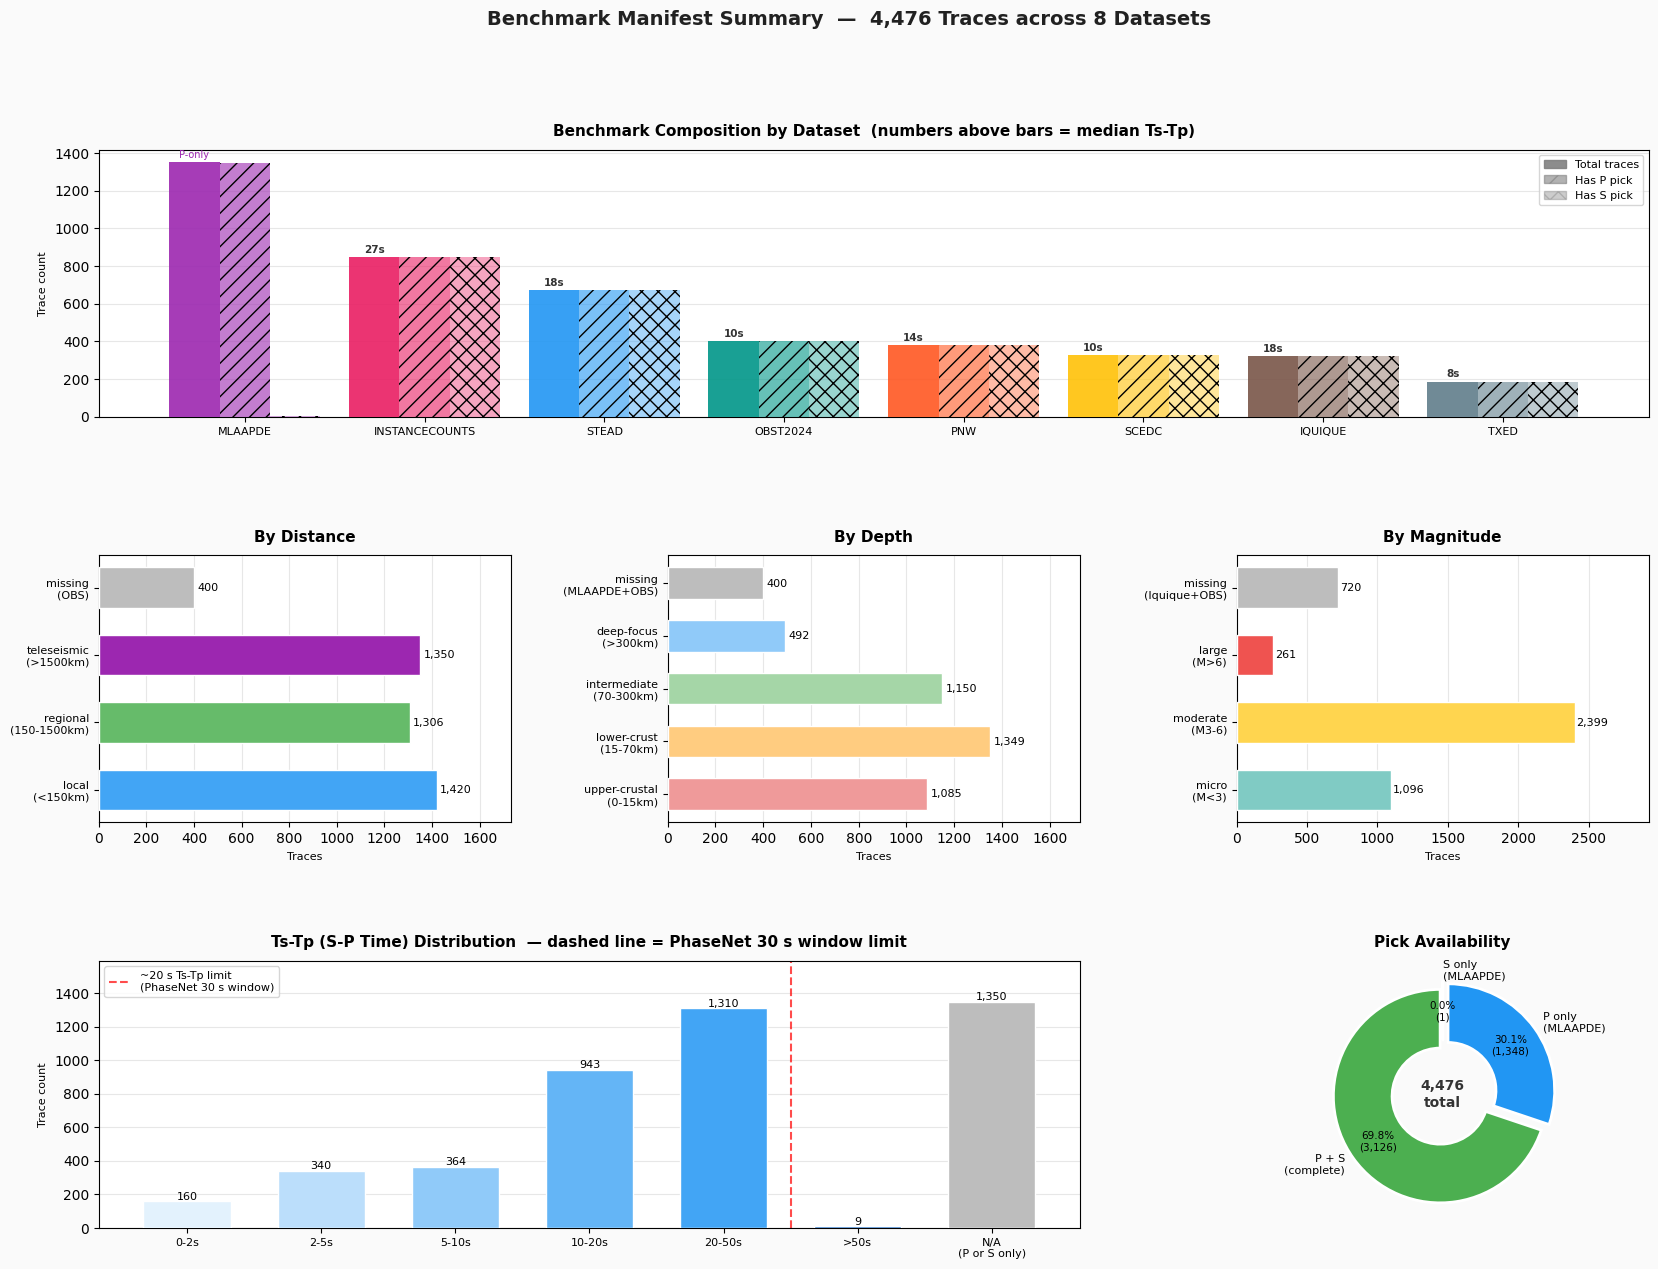

Saved → benchmark_summary.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ── Colour palette ────────────────────────────────────────────────────────────
C_P    = '#2196F3'   # blue  — P pick
C_S    = '#FF9800'   # amber — S pick
C_BOTH = '#4CAF50'   # green — both
C_MISS = '#BDBDBD'   # grey  — missing / N/A
C_TELE = '#9C27B0'   # purple — teleseismic

DS_COLORS = {
    'mlaapde':        '#9C27B0',
    'instancecounts': '#E91E63',
    'stead':          '#2196F3',
    'obst2024':       '#009688',
    'pnw':            '#FF5722',
    'scedc':          '#FFC107',
    'iquique':        '#795548',
    'txed':           '#607D8B',
}

# ── Data ──────────────────────────────────────────────────────────────────────
datasets     = ['mlaapde','instancecounts','stead','obst2024','pnw','scedc','iquique','txed']
ds_n         = [1350, 845, 672, 400, 378, 326, 320, 185]
ds_p         = [1349, 845, 672, 400, 378, 326, 320, 185]
ds_s         = [   1, 845, 672, 400, 378, 326, 320, 185]
ds_tstp      = [None, 26.6, 17.9, 10.4, 13.9, 9.9, 18.2, 8.5]

dist_labels  = ['local\n(<150km)', 'regional\n(150-1500km)', 'teleseismic\n(>1500km)', 'missing\n(OBS)']
dist_counts  = [1420, 1306, 1350, 400]
dist_colors  = ['#42A5F5','#66BB6A', C_TELE, C_MISS]

depth_labels = ['upper-crustal\n(0-15km)','lower-crust\n(15-70km)',
                'intermediate\n(70-300km)','deep-focus\n(>300km)','missing\n(MLAAPDE+OBS)']
depth_counts = [1085, 1349, 1150, 492, 400]
depth_colors = ['#EF9A9A','#FFCC80','#A5D6A7','#90CAF9', C_MISS]

mag_labels   = ['micro\n(M<3)','moderate\n(M3-6)','large\n(M>6)','missing\n(Iquique+OBS)']
mag_counts   = [1096, 2399, 261, 720]
mag_colors   = ['#80CBC4','#FFD54F','#EF5350', C_MISS]

tstp_labels  = ['0-2s','2-5s','5-10s','10-20s','20-50s','>50s','N/A\n(P or S only)']
tstp_counts  = [160, 340, 364, 943, 1310, 9, 1350]
tstp_colors  = ['#E3F2FD','#BBDEFB','#90CAF9','#64B5F6','#42A5F5','#1565C0', C_MISS]

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

TITLE_KW  = dict(fontsize=11, fontweight='bold', pad=10)
LABEL_KW  = dict(fontsize=8)
TICK_KW   = dict(fontsize=8)

# ── Panel 1 (top, full width): Dataset breakdown ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
x   = np.arange(len(datasets))
w   = 0.28

bars_n = ax1.bar(x - w,   ds_n, width=w, color=[DS_COLORS[d] for d in datasets],
                  label='Total', alpha=0.9, zorder=3)
bars_p = ax1.bar(x,       ds_p, width=w, color=[DS_COLORS[d] for d in datasets],
                  label='Has P', alpha=0.6, zorder=3, hatch='//')
bars_s = ax1.bar(x + w,   ds_s, width=w, color=[DS_COLORS[d] for d in datasets],
                  label='Has S', alpha=0.4, zorder=3, hatch='xx')

# Annotate median Ts-Tp above each Total bar
for i, (bar, ts) in enumerate(zip(bars_n, ds_tstp)):
    if ts is not None:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{ts:.0f}s', ha='center', va='bottom', fontsize=7.5,
                 color='#333333', fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 'P-only', ha='center', va='bottom', fontsize=7, color=C_TELE)

ax1.set_xticks(x)
ax1.set_xticklabels([d.upper() for d in datasets], **TICK_KW)
ax1.set_ylabel('Trace count', **LABEL_KW)
ax1.set_title('Benchmark Composition by Dataset  (numbers above bars = median Ts-Tp)', **TITLE_KW)
ax1.set_facecolor('white')
ax1.yaxis.grid(True, alpha=0.3, zorder=0)
ax1.set_axisbelow(True)

# Custom legend
total_patch = mpatches.Patch(color='grey', alpha=0.9, label='Total traces')
p_patch     = mpatches.Patch(color='grey', alpha=0.6, hatch='//', label='Has P pick')
s_patch     = mpatches.Patch(color='grey', alpha=0.4, hatch='xx', label='Has S pick')
ax1.legend(handles=[total_patch, p_patch, s_patch], fontsize=8, loc='upper right')

# ── Panel 2 (middle-left): Distance ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.barh(dist_labels, dist_counts, color=dist_colors, edgecolor='white', height=0.6, zorder=3)
for bar, count in zip(bars, dist_counts):
    ax2.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', **LABEL_KW)
ax2.set_xlim(0, max(dist_counts) * 1.22)
ax2.set_title('By Distance', **TITLE_KW)
ax2.set_xlabel('Traces', **LABEL_KW)
ax2.tick_params(axis='y', labelsize=8)
ax2.set_facecolor('white')
ax2.xaxis.grid(True, alpha=0.3, zorder=0); ax2.set_axisbelow(True)

# ── Panel 3 (middle-centre): Depth ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
bars = ax3.barh(depth_labels, depth_counts, color=depth_colors, edgecolor='white', height=0.6, zorder=3)
for bar, count in zip(bars, depth_counts):
    ax3.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', **LABEL_KW)
ax3.set_xlim(0, max(depth_counts) * 1.28)
ax3.set_title('By Depth', **TITLE_KW)
ax3.set_xlabel('Traces', **LABEL_KW)
ax3.tick_params(axis='y', labelsize=8)
ax3.set_facecolor('white')
ax3.xaxis.grid(True, alpha=0.3, zorder=0); ax3.set_axisbelow(True)

# ── Panel 4 (middle-right): Magnitude ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
bars = ax4.barh(mag_labels, mag_counts, color=mag_colors, edgecolor='white', height=0.6, zorder=3)
for bar, count in zip(bars, mag_counts):
    ax4.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', **LABEL_KW)
ax4.set_xlim(0, max(mag_counts) * 1.22)
ax4.set_title('By Magnitude', **TITLE_KW)
ax4.set_xlabel('Traces', **LABEL_KW)
ax4.tick_params(axis='y', labelsize=8)
ax4.set_facecolor('white')
ax4.xaxis.grid(True, alpha=0.3, zorder=0); ax4.set_axisbelow(True)

# ── Panel 5 (bottom-left + centre): Ts-Tp distribution ───────────────────────
ax5 = fig.add_subplot(gs[2, :2])
bars = ax5.bar(tstp_labels, tstp_counts, color=tstp_colors, edgecolor='white',
               width=0.65, zorder=3)
for bar, count in zip(bars, tstp_counts):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count:,}', ha='center', **LABEL_KW)
ax5.set_ylabel('Trace count', **LABEL_KW)
ax5.set_title('Ts-Tp (S-P Time) Distribution  '
              '— dashed line = PhaseNet 30 s window limit', **TITLE_KW)
ax5.axvline(x=4.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label='~20 s Ts-Tp limit\n(PhaseNet 30 s window)')
ax5.set_ylim(0, max(tstp_counts) * 1.18)
ax5.legend(fontsize=8, loc='upper left')
ax5.set_facecolor('white')
ax5.yaxis.grid(True, alpha=0.3, zorder=0); ax5.set_axisbelow(True)
ax5.tick_params(axis='x', labelsize=8)

# ── Panel 6 (bottom-right): Pick availability donut ──────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
pick_labels  = ['P + S\n(complete)', 'P only\n(MLAAPDE)', 'S only\n(MLAAPDE)']
pick_counts  = [3126, 1349, 1]
pick_colors  = [C_BOTH, C_P, C_S]
pick_explode = [0.03, 0.06, 0.06]

wedges, texts, autotexts = ax6.pie(
    pick_counts, labels=pick_labels, colors=pick_colors,
    explode=pick_explode, autopct=lambda p: f'{p:.1f}%\n({int(p*4476/100):,})',
    startangle=90, pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=8),
)
for at in autotexts:
    at.set_fontsize(7.5)
ax6.set_title('Pick Availability', **TITLE_KW)

# Centre label
ax6.text(0, 0, f'4,476\ntotal', ha='center', va='center',
         fontsize=10, fontweight='bold', color='#333333')

# ── Main title ────────────────────────────────────────────────────────────────
fig.suptitle('Benchmark Manifest Summary  —  4,476 Traces across 8 Datasets',
             fontsize=14, fontweight='bold', y=0.98, color='#212121')

plt.savefig('benchmark_summary.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → benchmark_summary.png')